<a href="https://colab.research.google.com/github/chaiyawat19/DataScinceLab/blob/main/Lab10_Clustering_TelUsage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Partition Clustering

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

K-Mean Clutering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/LabDataScince/Lab10/cust_telusage.csv')
df.head(10)

In [ ]:
df.dtypes

In [ ]:
from sklearn.preprocessing import LabelEncoder
# creating instance of labelencoder
labelencoder = LabelEncoder()
df['Gender'] = labelencoder.fit_transform(df['Gender'])

In [ ]:
df

In [ ]:
from sklearn.cluster import KMeans
clustering_model = KMeans(n_clusters=3)
clustering_model

In [ ]:
output_cluster = clustering_model.fit_predict(df)

In [ ]:
import matplotlib.pyplot as plt
# k means determine k
distortions = []
K = range(1,10)
for k in K:
    clustering_model = KMeans(n_clusters=k)
    clustering_model.fit(df)
    distortions.append(clustering_model.inertia_)
# Plot the elbow
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [ ]:
df['cluster'] = output_cluster
df

In [ ]:
import plotly.express as px
fig = px.scatter_matrix(df, dimensions=["Age","Gender", "SMS", "Phone"], color="cluster")
fig.show()

In [ ]:
cluster1 = df[df['cluster']== 0]
cluster1.describe()

In [ ]:
cluster1['Gender'].mode()

In [ ]:
import statistics
print("Mode of given data set is % s" % (statistics.mode(cluster1['Gender'])))

In [ ]:
cluster1

In [ ]:
cluster2 = df[df['cluster']== 1]
cluster2.describe()

In [ ]:
cluster2['Gender'].mode()

In [ ]:
import statistics
print("Mode of given data set is % s" % (statistics.mode(cluster2['Gender'])))

In [ ]:
cluster2

In [ ]:
cluster3 = df[df['cluster']== 2]
cluster3.describe()

In [ ]:
cluster3['Gender'].mode()

In [ ]:
import statistics
print("Mode of given data set is % s" % (statistics.mode(cluster3['Gender'])))

In [ ]:
cluster3

In [ ]:
#Initiating PCA to reduce dimentions aka features to 3
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca.fit(df)
PCA_ds = pd.DataFrame(pca.transform(df), columns=(["col1","col2","col3"]))
PCA_ds.describe().T

In [ ]:
import plotly.express as px
fig = px.scatter(df, x="SMS", y="Phone", color="cluster",
                 size='Age', hover_data=['Age'])
fig.show()

Evaluation
Sum of distances of samples to their closest cluster center

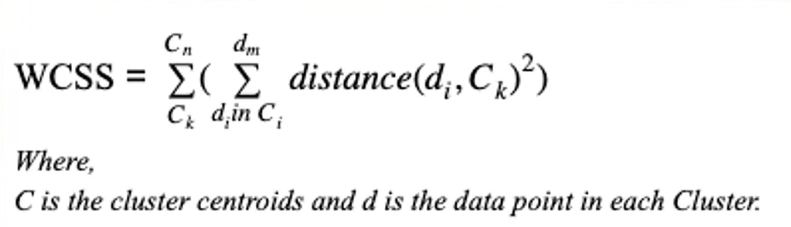

In [ ]:
sse = clustering_model.inertia_
sse

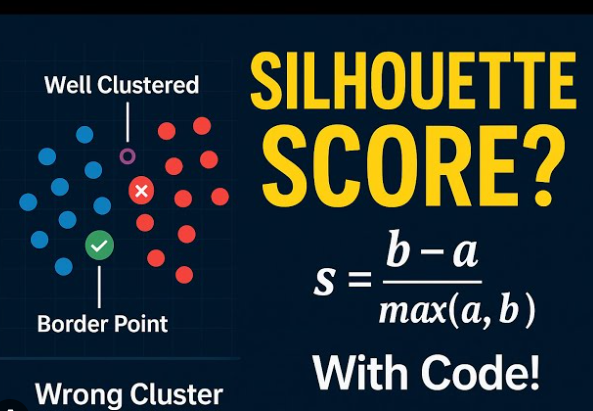

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(df, output_cluster)
print(f"The Silhouette Score is: {silhouette_avg}")